# Project 1: Advanced EDA & Feature Engineering

## Objective
Perform exploratory data analysis and feature engineering on an e-commerce dataset.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np 

In [2]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")


In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.shape

(1200, 14)

In [5]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [7]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [8]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


## Handling the missing values


In [9]:
# handling the missing values 
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [10]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [11]:
print(df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [12]:
# duplicate records
print(df.duplicated().sum())

0


In [13]:
# outlier detection using IQR(Interquartile Range)
import matplotlib.pyplot as plt
import seaborn as sns



## outlier detection and treatment

In [26]:
# Outlier Detection using IQR
num_cols=["Quantity","UnitPrice","ItemsInCart","TotalPrice"]

for col in num_cols:

    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    outliers=df[(df[col]<lower_bound)|(df[col]>upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

Quantity: 0 outliers
UnitPrice: 0 outliers
ItemsInCart: 0 outliers
TotalPrice: 0 outliers


In [27]:
# outlier treatment
df["TotalPrice"]=np.clip(df["TotalPrice"],
                         lower_bound,
                         upper_bound)

In [28]:
print("TotalPrice:",len(outliers),"outliers")

TotalPrice: 0 outliers


## Feature Engineering


In [29]:
## Feature Engineering
#Feature 1: DiscountUsed
df["DiscountUsed"] = (df["CouponCode"] != "No Coupon").astype(int)

In [30]:
#Feature 2: OrderMonth
df["Date"] = pd.to_datetime(df["Date"])
df["OrderMonth"] = df["Date"].dt.month

In [24]:
#Feature 3: OrderYear
df["OrderYear"] = df["Date"].dt.year

In [25]:
#Feature 4: WeekendOrder
df["WeekendOrder"] = (df["Date"].dt.dayofweek >= 5).astype(int)

In [31]:
#Feature 5: AveragePricePerItem
df["AveragePricePerItem"] = df["TotalPrice"] / df["Quantity"]

In [32]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,DiscountUsed,OrderMonth,WeekendOrder,OrderYear,AveragePricePerItem
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,1,0,2023,570.62
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,1,8,0,2024,151.35
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,1,2,0,2024,550.68
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,1,10,1,2023,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,1,5,0,2025,626.01


In [34]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'DiscountUsed', 'OrderMonth', 'WeekendOrder', 'OrderYear',
       'AveragePricePerItem'],
      dtype='object')

## Data visualization (EDA)

#### Histogram of TotalPrice 


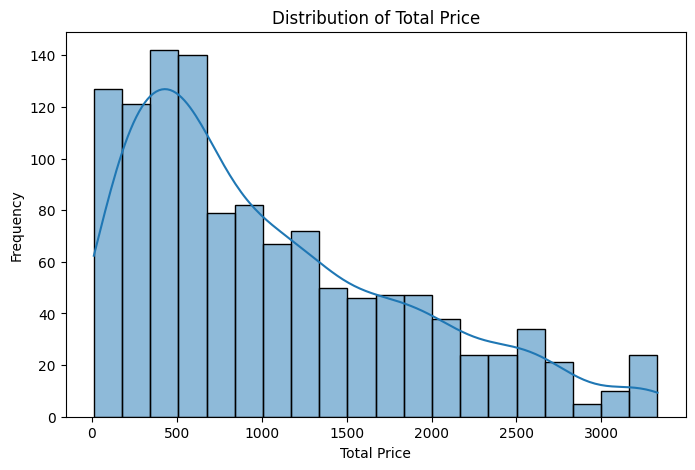

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df["TotalPrice"], bins=20, kde=True)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

#### Boxplot of TotalPrice

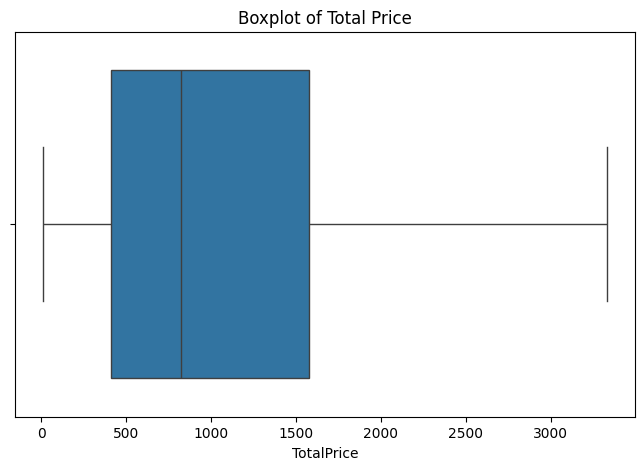

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["TotalPrice"])
plt.title("Boxplot of Total Price")
plt.show()

#### Countplot of Payment Methods

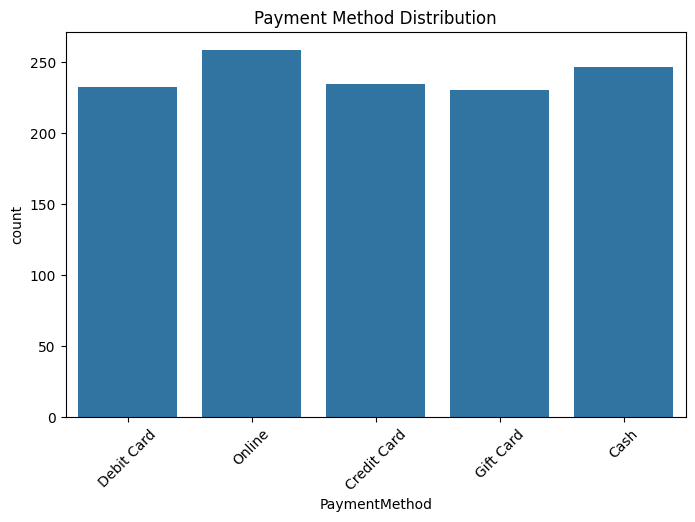

In [45]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["PaymentMethod"])
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

#### Countplot of Order Status

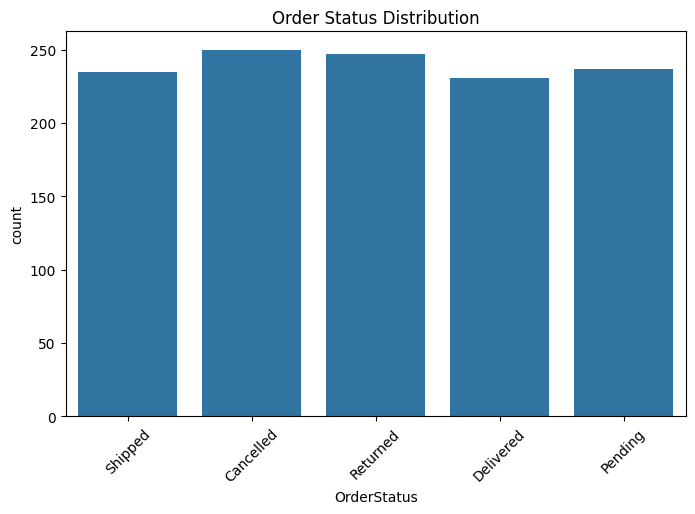

In [46]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["OrderStatus"])
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()

#### Correlation Heatmap


In [ ]:
## Select numerical columns
numeric_df = df.select_dtypes(include=['int64','float64'])

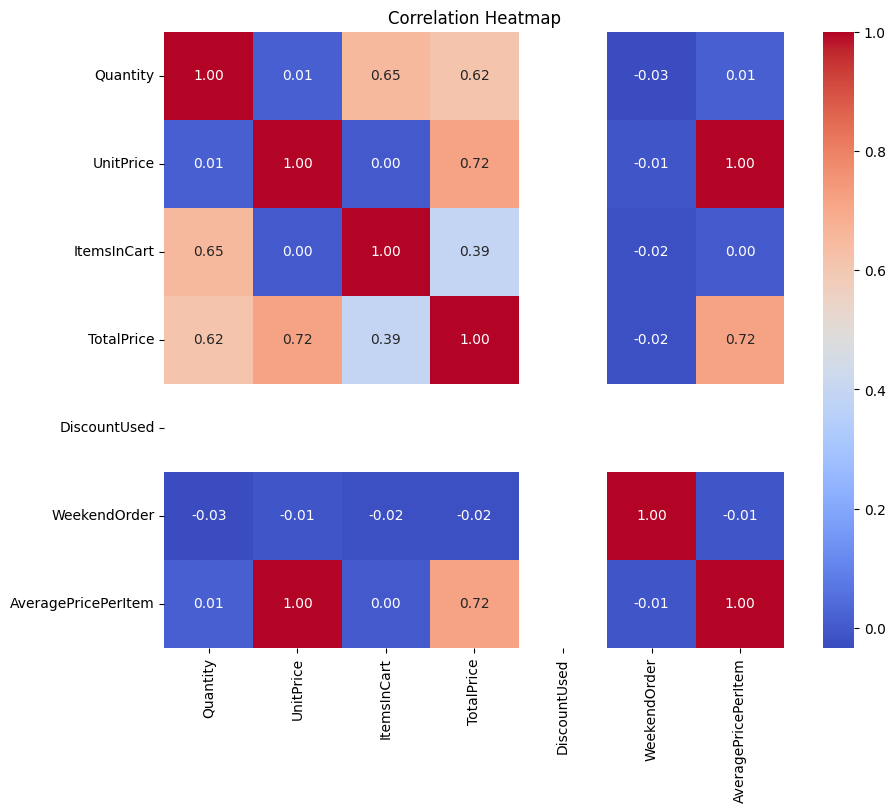

In [48]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

#### Monthly Orders Analysis

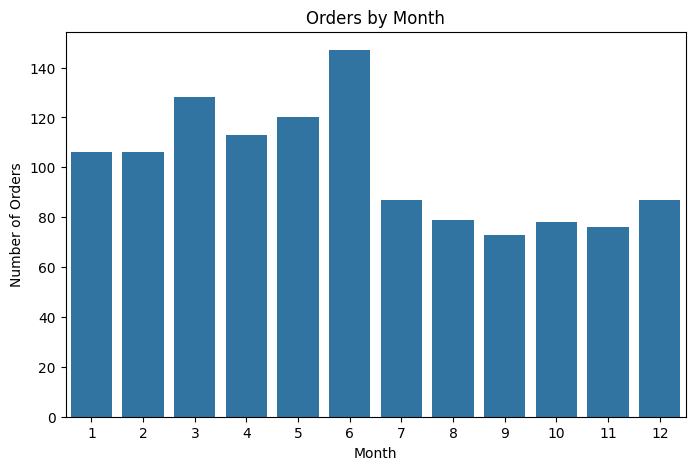

In [49]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["OrderMonth"])
plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

#### Quantity vs TotalPrice

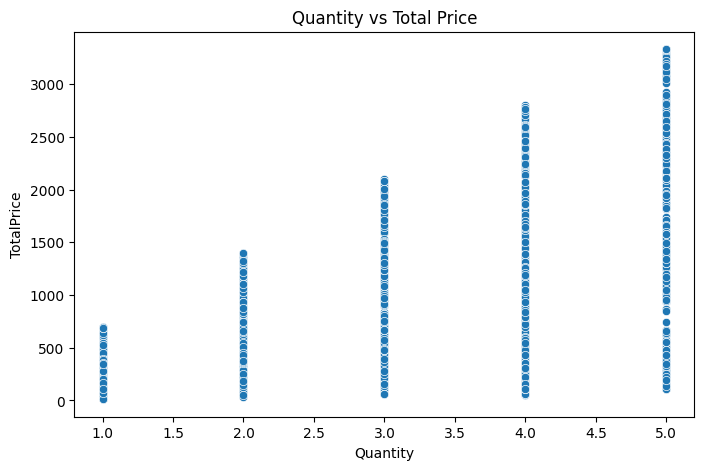

In [50]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Quantity"], y=df["TotalPrice"])
plt.title("Quantity vs Total Price")
plt.show()

In [51]:
### Save the clean Dataset
df.to_csv("cleaned_dataset.csv", index=False)

In [53]:
print(df.shape)

(1200, 19)


In [54]:
print(df.columns)

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'DiscountUsed', 'OrderMonth', 'WeekendOrder', 'OrderYear',
       'AveragePricePerItem'],
      dtype='object')


In [55]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,DiscountUsed,OrderMonth,WeekendOrder,OrderYear,AveragePricePerItem
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,1,0,2023,570.62
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,1,8,0,2024,151.35
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,1,2,0,2024,550.68
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,1,10,1,2023,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,1,5,0,2025,626.01


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   OrderID              1200 non-null   object        
 1   Date                 1200 non-null   datetime64[ns]
 2   CustomerID           1200 non-null   object        
 3   Product              1200 non-null   object        
 4   Quantity             1200 non-null   int64         
 5   UnitPrice            1200 non-null   float64       
 6   ShippingAddress      1200 non-null   object        
 7   PaymentMethod        1200 non-null   object        
 8   OrderStatus          1200 non-null   object        
 9   TrackingNumber       1200 non-null   object        
 10  ItemsInCart          1200 non-null   int64         
 11  CouponCode           1200 non-null   object        
 12  ReferralSource       1200 non-null   object        
 13  TotalPrice           1200 non-nul

In [57]:

print(df.isnull().sum())

OrderID                0
Date                   0
CustomerID             0
Product                0
Quantity               0
UnitPrice              0
ShippingAddress        0
PaymentMethod          0
OrderStatus            0
TrackingNumber         0
ItemsInCart            0
CouponCode             0
ReferralSource         0
TotalPrice             0
DiscountUsed           0
OrderMonth             0
WeekendOrder           0
OrderYear              0
AveragePricePerItem    0
dtype: int64


# Conclusion

- Missing values were handled successfully.
- Outliers were detected and treated using the IQR method.
- Five new features were created.
- Data visualization was performed.
- The cleaned dataset was saved for further analysis.